# Reproducibility: recomputing the reported quantities from the per-epoch CSVs

This notebook recomputes the feature-norm thresholds, collapse times, effect
sizes, the between-pair test, the intervention statistics, and the predictive
lead time **directly from the per-epoch training logs**. Run it top to bottom.

Definitions and data sources:
- `T_NC` = first **Phase-2** epoch with `NC1 < threshold`; `fn* = feat_norm` at that epoch.
- The depth-5 / ReLU / weight-decay 1e-4 / MNIST seed-0 run is logged as
  `mnist_twophase.csv`; depth-2 and depth-3 use the `*_ext.csv` logs; GELU uses
  the seeds in `gelu_summary.csv`.
- Standard deviations are **sample** standard deviations (ddof=1). 95% intervals
  use the Student-t multiplier for the cell's seed count.

Dependencies: numpy, pandas, scipy.

### Running in Google Colab
Auto-detected. Either mount Google Drive (put the CSV folders under
`MyDrive/NC_revision/`, edit `DRIVE_ROOT` if needed) or use the optional upload
cell to drop the CSVs / a zip into `/content`. Locally, no changes are needed.

In [1]:
import os, sys, numpy as np, pandas as pd
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = "/content/drive/MyDrive/NC_revision"      # <-- edit if needed
    CSV_DIRS = [DRIVE_ROOT, os.path.join(DRIVE_ROOT,"results"),
                os.path.join(DRIVE_ROOT,"Results"), os.path.join(DRIVE_ROOT,"Results "),
                "/content"]
else:
    try: NB_DIR = Path(__file__).resolve().parent
    except NameError: NB_DIR = Path.cwd()
    REPO = NB_DIR.parent
    CSV_DIRS = [str(REPO/"results"), str(NB_DIR/"results"), str(NB_DIR)]

def find(name):
    for d in CSV_DIRS:
        p = os.path.join(str(d), name)
        if os.path.exists(p): return p
    return None

print(f"IN_COLAB = {IN_COLAB}")
for d in CSV_DIRS:
    nf = len([f for f in os.listdir(d) if f.endswith(".csv")]) if os.path.isdir(str(d)) else 0
    print(f"  {'[OK]' if os.path.isdir(str(d)) else '[--]'} {d}  ({nf} csv)")
_need = ["mnist_twophase.csv","gelu_summary.csv","resnet20_mnist_summary.csv",
         "cifar10_summary.csv","sweep_width.csv","fmnist_resnet20_s0.csv"]
_miss = [k for k in _need if find(k) is None]
assert not _miss, f"CSVs not found: {_miss} (in Colab fix DRIVE_ROOT or upload them)."
print("All required CSVs found.")

IN_COLAB = False
  [OK] /sessions/focused-charming-brahmagupta/mnt/NC-paper/Supplementary Material/results  (100 csv)
  [--] /sessions/focused-charming-brahmagupta/mnt/NC-paper/Supplementary Material/notebooks/results  (0 csv)
  [OK] /sessions/focused-charming-brahmagupta/mnt/NC-paper/Supplementary Material/notebooks  (0 csv)
All required CSVs found.


In [2]:
# OPTIONAL (Colab) -- upload CSVs or a .zip into /content instead of using Drive
if IN_COLAB:
    from google.colab import files
    import zipfile
    up = files.upload()
    for fn in up:
        if fn.lower().endswith(".zip"):
            with zipfile.ZipFile(fn) as z: z.extractall("/content")
    for d in ["/content/results","/content"]:
        if os.path.isdir(d) and d not in CSV_DIRS: CSV_DIRS.insert(0, d)

In [3]:
# helpers
def load(pref, s, ext=False):
    for c in ([f"{pref}_s{s}_ext.csv"] if ext else []) + [f"{pref}_s{s}.csv"]:
        p = find(c)
        if p: return pd.read_csv(p)
    if pref=="depth5" and s==0: return pd.read_csv(find("mnist_twophase.csv"))
    return None
def phase2(df):
    x = df[df.phase==2] if "phase" in df.columns else df
    if "phase" in df.columns and len(x)==0: x = df
    return x.dropna(subset=["nc1","feat_norm"]).reset_index(drop=True)
def fn_star(df, th, method="crossing"):
    s = phase2(df)
    if len(s)==0: return (None,None)
    if method=="minNC1":
        i=s.nc1.idxmin(); return float(s.loc[i,"feat_norm"]), int(s.loc[i,"epoch"])
    c=s[s.nc1<th]; return (float(c.iloc[0].feat_norm),int(c.iloc[0].epoch)) if len(c) else (None,None)
def collect(pref, th, ext=False, method="crossing", nseed=3):
    fns,tncs=[],[]
    for s in range(nseed):
        df=load(pref,s,ext)
        if df is None: continue
        v,e=fn_star(df,th,method)
        if v is not None: fns.append(v); tncs.append(e)
    return np.array(fns), np.array(tncs)
def msd(a): return (a.mean(), a.std(ddof=1) if len(a)>1 else 0.0)
def tmult(n): return {2:12.706,3:4.303,4:3.182,5:2.776,12:2.201}.get(n,2.0)
def tci(v):
    n=len(v); se=v.std(ddof=1)/np.sqrt(n); t=tmult(n); return v.mean()-t*se, v.mean()+t*se

## Depth sweep

In [4]:
print(f'{"depth":6}{"N":>3}{"T_NC":>12}{"fn*":>16}')
for d,th,ext in [(2,0.05,True),(3,0.05,True),(5,0.01,False),(7,0.01,False)]:
    f,t=collect(f"depth{d}",th,ext); (mf,sf)=msd(f);(mt,st)=msd(t)
    print(f'{d:<6}{len(f):>3}   {mt:.0f} +/- {st:.0f}     {mf:.3f} +/- {sf:.3f}')

depth   N        T_NC             fn*
2       3   273 +/- 67     1.428 +/- 0.323
3       3   250 +/- 35     1.417 +/- 0.276
5       3   297 +/- 12     1.077 +/- 0.025
7       3   340 +/- 10     1.112 +/- 0.040


## Activation sweep

In [5]:
rows=[("ReLU","depth5",0.01,False,"crossing"),("LeakyReLU","actLeakyReLU",0.01,False,"crossing"),
      ("Tanh","actTanh",0.05,False,"crossing"),("SiLU","actSiLU_extended",None,False,"minNC1")]
for nm,pref,th,ext,m in rows:
    f,t=collect(pref,th,ext,m);(mf,sf)=msd(f);(mt,st)=msd(t)
    print(f'{nm:<10} N={len(f)}  T_NC={mt:.0f} +/- {st:.0f}   fn*={mf:.3f} +/- {sf:.3f}')
g=pd.read_csv(find("gelu_summary.csv"))
print(f'{"GELU":<10} N={len(g)}  T_NC={g.T_NC.mean():.0f} +/- {g.T_NC.std(ddof=1):.0f}   fn*={g.fn.mean():.3f} +/- {g.fn.std(ddof=1):.3f}')

ReLU       N=3  T_NC=297 +/- 12   fn*=1.077 +/- 0.025
LeakyReLU  N=3  T_NC=280 +/- 26   fn*=1.026 +/- 0.029
Tanh       N=3  T_NC=220 +/- 0   fn*=1.325 +/- 0.040
SiLU       N=3  T_NC=1027 +/- 179   fn*=3.257 +/- 0.188
GELU       N=4  T_NC=265 +/- 24   fn*=2.128 +/- 0.515


## Weight-decay sweep  (1e-4 == depth-5 baseline)

In [6]:
for lam,pref in [("1e-5","wd1e-05"),("5e-5","wd5e-05"),("1e-4","depth5")]:
    f,t=collect(pref,0.01);(mf,sf)=msd(f);(mt,st)=msd(t)
    print(f'lambda={lam:<5} N={len(f)}  T_NC={mt:.0f} +/- {st:.0f}   fn*={mf:.3f} +/- {sf:.3f}')
print("lambda=5e-4 : no NC1<0.01 crossing within budget (DNF)")

lambda=1e-5  N=3  T_NC=380 +/- 50   fn*=1.035 +/- 0.087
lambda=5e-5  N=3  T_NC=290 +/- 10   fn*=0.983 +/- 0.006
lambda=1e-4  N=3  T_NC=297 +/- 12   fn*=1.077 +/- 0.025
lambda=5e-4 : no NC1<0.01 crossing within budget (DNF)


## Width sweep

In [7]:
w=pd.read_csv(find("sweep_width.csv"))
for wd in [128,256,512,1024]:
    s=w[w.width==wd]
    print(f'width={wd:<5} N={len(s)}  T_NC={s.T_NC.mean():.0f} +/- {s.T_NC.std(ddof=1):.0f}   '
          f'fn*={s.fn.mean():.3f} +/- {s.fn.std(ddof=1):.3f}   CV={s.fn.std(ddof=1)/s.fn.mean()*100:.1f}%')

width=128   N=3  T_NC=383 +/- 15   fn*=1.241 +/- 0.105   CV=8.4%
width=256   N=3  T_NC=327 +/- 12   fn*=1.125 +/- 0.041   CV=3.6%
width=512   N=3  T_NC=310 +/- 10   fn*=1.096 +/- 0.017   CV=1.6%
width=1024  N=3  T_NC=257 +/- 12   fn*=1.080 +/- 0.059   CV=5.4%


## Feature-norm threshold by (model, dataset) pair

In [8]:
def pair_vals(specs):
    out=[]
    for pref,th,ext in specs: f,_=collect(pref,th,ext); out+=list(f)
    return np.array(out)
PAIRS={
 "MNIST/MLP-5":   [("depth5",.01,False),("depth7",.01,False),("wd1e-05",.01,False),("wd5e-05",.01,False)],
 "MNIST/ResNet-20":[("__summary__","resnet20_mnist_summary.csv",None)],
 "Fashion/MLP-5": [("fmnist",.05,False)],
 "Fashion/ResNet-20":[("fmnist_resnet20",.01,False)],
 "CIFAR-10/MLP-5":[("mlp5_cifar10",.05,False)],
 "CIFAR-10/ResNet-20":[("__summary__","cifar10_summary.csv",None)],
}
PAIR_VALS={}
for k,sp in PAIRS.items():
    if sp[0][0]=="__summary__": v=pd.read_csv(find(sp[0][1])).fn.values
    else: v=pair_vals(sp)
    PAIR_VALS[k]=np.array(v); lo,hi=tci(np.array(v))
    print(f'{k:20} N={len(v):2d}  fn*={v.mean():.3f} +/- {v.std(ddof=1):.3f}   95% CI=[{lo:.3f},{hi:.3f}]   CV={v.std(ddof=1)/v.mean()*100:.1f}%')

MNIST/MLP-5          N=12  fn*=1.052 +/- 0.066   95% CI=[1.010,1.093]   CV=6.2%
MNIST/ResNet-20      N= 3  fn*=5.867 +/- 0.034   95% CI=[5.781,5.952]   CV=0.6%
Fashion/MLP-5        N= 3  fn*=1.367 +/- 0.077   95% CI=[1.176,1.559]   CV=5.6%
Fashion/ResNet-20    N= 3  fn*=1.678 +/- 0.012   95% CI=[1.648,1.708]   CV=0.7%
CIFAR-10/MLP-5       N= 3  fn*=0.900 +/- 0.065   95% CI=[0.738,1.063]   CV=7.3%
CIFAR-10/ResNet-20   N= 3  fn*=1.515 +/- 0.008   95% CI=[1.494,1.535]   CV=0.5%


## Architecture x dataset effect sizes

In [9]:
m={k:PAIR_VALS[k].mean() for k in PAIR_VALS}
def pct(a,b): return (m[b]-m[a])/m[a]*100
print(f'architecture (MLP-5 -> ResNet-20):  MNIST {pct("MNIST/MLP-5","MNIST/ResNet-20"):+.1f}% | '
      f'Fashion {pct("Fashion/MLP-5","Fashion/ResNet-20"):+.1f}% | CIFAR-10 {pct("CIFAR-10/MLP-5","CIFAR-10/ResNet-20"):+.1f}%')
print(f'dataset (MNIST -> CIFAR-10):  MLP-5 {pct("MNIST/MLP-5","CIFAR-10/MLP-5"):+.1f}% | ResNet-20 {pct("MNIST/ResNet-20","CIFAR-10/ResNet-20"):+.1f}%')
print(f'feature-norm compression (baseline): {27/1.063:.1f}x ; width effect: {(1-1.080/1.241)*100:.0f}%')

architecture (MLP-5 -> ResNet-20):  MNIST +457.9% | Fashion +22.7% | CIFAR-10 +68.2%
dataset (MNIST -> CIFAR-10):  MLP-5 -14.4% | ResNet-20 -74.2%
feature-norm compression (baseline): 25.4x ; width effect: 13%


## Between-pair test
Within-group variances differ markedly across pairs (the ResNet-20 cells have
CV well below 1% while the MLP-5 cells are several percent), so we use the
rank-based **Kruskal-Wallis** test, which does not assume equal variance.

In [10]:
from scipy import stats
order=["MNIST/MLP-5","MNIST/ResNet-20","CIFAR-10/MLP-5","CIFAR-10/ResNet-20"]
H4,p4=stats.kruskal(*[PAIR_VALS[k] for k in order])
H6,p6=stats.kruskal(*[PAIR_VALS[k] for k in PAIR_VALS])
print(f'Kruskal-Wallis, four original pairs: H={H4:.2f}, df=3, p={p4:.4f}')
print(f'Kruskal-Wallis, all six cells:       H={H6:.2f}, df=5, p={p6:.4f}')
# epsilon-squared effect size: (H - k + 1)/(n - k)
n4=sum(len(PAIR_VALS[k]) for k in order); n6=sum(len(v) for v in PAIR_VALS.values())
print(f'  effect size eps^2: four pairs={(H4-4+1)/(n4-4):.2f} (n={n4}); six cells={(H6-6+1)/(n6-6):.2f} (n={n6})')
# 95% CI overlap among all six cells
ks=list(PAIR_VALS); cis={k:tci(PAIR_VALS[k]) for k in ks}
ov=[(a,b) for i,a in enumerate(ks) for b in ks[i+1:]
    if not (cis[a][1]<cis[b][0] or cis[b][1]<cis[a][0])]
print("pairs with overlapping 95% CIs:", ov if ov else "none")

Kruskal-Wallis, four original pairs: H=15.75, df=3, p=0.0013
Kruskal-Wallis, all six cells:       H=23.34, df=5, p=0.0003
  effect size eps^2: four pairs=0.75 (n=21); six cells=0.87 (n=27)
pairs with overlapping 95% CIs: [('MNIST/MLP-5', 'CIFAR-10/MLP-5'), ('Fashion/MLP-5', 'CIFAR-10/ResNet-20')]


## Intervention experiment and predictive lead time

In [11]:
from scipy import stats
iv=pd.read_csv(find("intervention_summary.csv"))
for c in ["control","scale_down","scale_up"]:
    s=iv[iv.condition==c]
    print(f'{c:11} T_NC={s.T_NC.mean():.0f} +/- {s.T_NC.std(ddof=1):.0f}   fn*={s.fn_at_TNC.mean():.3f} +/- {s.fn_at_TNC.std(ddof=1):.3f}')
ct=iv[iv.condition=="control"].T_NC; dn=iv[iv.condition=="scale_down"].T_NC; up=iv[iv.condition=="scale_up"].T_NC
print(f'  T_NC difference vs control: scale-down p={stats.ttest_ind(ct,dn).pvalue:.2f}, scale-up p={stats.ttest_ind(ct,up).pvalue:.2f}')
pa=pd.read_csv(find("prediction_analysis.csv")); g=pa.gap.values
err=np.abs(g-62)
print(f'lead time (T_NC - T_cross): mean={g.mean():.0f} +/- {g.std(ddof=1):.0f} epochs over {len(g)} runs')
print(f'  per-run gaps         : {sorted(g.tolist())}')
print(f'  rule T_NC=T_cross+62 : MAE = {err.mean():.0f} epochs; absolute-error range = [{err.min():.0f}, {err.max():.0f}]; per-run errors = {sorted(err.tolist())}')

control     T_NC=287 +/- 35   fn*=1.103 +/- 0.020
scale_down  T_NC=317 +/- 6   fn*=1.093 +/- 0.033
scale_up    T_NC=317 +/- 46   fn*=1.054 +/- 0.049
  T_NC difference vs control: scale-down p=0.22, scale-up p=0.42
lead time (T_NC - T_cross): mean=62 +/- 37 epochs over 8 runs
  per-run gaps         : [10, 40, 50, 60, 60, 60, 80, 140]
  rule T_NC=T_cross+62 : MAE = 24 epochs; absolute-error range = [2, 78]; per-run errors = [2, 2, 2, 12, 18, 22, 52, 78]


## Additional reported quantities (completeness)
Baseline compression, pooled-sweep rows, threshold robustness, between-pair gap, per-seed values/ranges, and intervention rescaled norms.

In [12]:
# Baseline two-phase (MNIST, MLP-5, ReLU): feature-norm compression at collapse
bt = pd.read_csv(find("mnist_twophase.csv"))
peak = bt.feat_norm.max()
s2b  = bt[bt.phase==2] if "phase" in bt.columns else bt
cr0  = s2b[s2b.nc1<0.01].iloc[0]
print("Baseline two-phase:")
print(f"  peak fn (pre-collapse) = {peak:.1f}")
print(f"  fn* at collapse        = {cr0.feat_norm:.3f}  (T_NC = {int(cr0.epoch)})")
print(f"  compression            = {peak/cr0.feat_norm:.1f}x   (paper: '25-fold')")

Baseline two-phase:
  peak fn (pre-collapse) = 26.8
  fn* at collapse        = 1.063  (T_NC = 310)
  compression            = 25.2x   (paper: '25-fold')


In [13]:
# Pooled fn* by sweep (Table 'all conditions'), ddof=1
def _pool(specs):
    out=[]
    for pref,th,ext in specs:
        f,_=collect(pref,th,ext); out+=list(f)
    return np.array(out)
sw = pd.read_csv(find("sweep_width.csv"))
dep = _pool([("depth2",.05,True),("depth3",.05,True),("depth5",.01,False),("depth7",.01,False)])
wd  = _pool([("wd1e-05",.01,False),("wd5e-05",.01,False),("depth5",.01,False)])
wid = sw.fn.values
allrelu = _pool([("depth5",.01,False),("depth7",.01,False),("wd1e-05",.01,False),("wd5e-05",.01,False)])
for v in [128,256,1024]: allrelu = np.append(allrelu, sw[sw.width==v].fn.values)
for nm,a in [("Depth sweep",dep),("WD sweep",wd),("Width sweep",wid),("All ReLU (N=21)",allrelu)]:
    print(f"{nm:16} N={len(a):2d}  fn*={a.mean():.3f} +/- {a.std(ddof=1):.3f}  CV={a.std(ddof=1)/a.mean()*100:.1f}%")

Depth sweep      N=12  fn*=1.259 +/- 0.251  CV=19.9%
WD sweep         N= 9  fn*=1.032 +/- 0.061  CV=5.9%
Width sweep      N=12  fn*=1.135 +/- 0.085  CV=7.5%
All ReLU (N=21)  N=21  fn*=1.093 +/- 0.092  CV=8.4%


In [14]:
# Threshold robustness: fn* at NC1<0.01 vs NC1<0.02 (ratio)
def _mfn(pref,th,ext=False,width=None):
    if width is not None:
        vs=[fn_star(pd.read_csv(find(f"width{width}_s{s}.csv")),th)[0]
            for s in range(3) if find(f"width{width}_s{s}.csv")]
        return np.mean([v for v in vs if v is not None])
    f,_=collect(pref,th,ext); return f.mean()
rows=[("Depth=5","depth5",False,None),("Depth=7","depth7",False,None),
      ("Width=128",None,None,128),("Width=256",None,None,256),
      ("lambda=1e-5","wd1e-05",False,None),("lambda=5e-5","wd5e-05",False,None)]
rat=[]
for nm,pref,ext,wv in rows:
    a=_mfn(pref,0.01,ext,wv); b=_mfn(pref,0.02,ext,wv); rat.append(b/a)
    print(f"{nm:12} @0.01={a:.3f}  @0.02={b:.3f}  ratio={b/a:.2f}")
rat=np.array(rat)
print(f"mean ratio = {rat.mean():.2f} +/- {rat.std(ddof=1):.2f}   range [{rat.min():.2f}, {rat.max():.2f}]")

Depth=5      @0.01=1.077  @0.02=1.251  ratio=1.16
Depth=7      @0.01=1.112  @0.02=0.953  ratio=0.86
Width=128    @0.01=1.241  @0.02=1.276  ratio=1.03
Width=256    @0.01=1.125  @0.02=1.222  ratio=1.09
lambda=1e-5  @0.01=1.035  @0.02=1.197  ratio=1.16
lambda=5e-5  @0.01=0.983  @0.02=1.150  ratio=1.17
mean ratio = 1.08 +/- 0.12   range [0.86, 1.17]


In [15]:
# Between-pair gap and per-seed values / ranges
mm = PAIR_VALS["MNIST/MLP-5"].mean()
cr = PAIR_VALS["CIFAR-10/ResNet-20"]; rn = PAIR_VALS["MNIST/ResNet-20"]
print(f"Between-pair gap (CIFAR-10/ResNet-20 vs MNIST/MLP-5) = {(cr.mean()-mm)/mm*100:.0f}%  (pair-mean ref)")
print(f"  same gap vs two-phase baseline 1.063               = {(cr.mean()-1.063)/1.063*100:.0f}%")
print(f"CIFAR-10/ResNet-20 seeds = {sorted(np.round(cr,3).tolist())}  range [{cr.min():.3f}, {cr.max():.3f}]  (T_NC=660 all seeds)")
print(f"ResNet-20/MNIST seeds    = {sorted(np.round(rn,3).tolist())}")

Between-pair gap (CIFAR-10/ResNet-20 vs MNIST/MLP-5) = 44%  (pair-mean ref)
  same gap vs two-phase baseline 1.063               = 42%
CIFAR-10/ResNet-20 seeds = [1.506, 1.517, 1.521]  range [1.506, 1.521]  (T_NC=660 all seeds)
ResNet-20/MNIST seeds    = [5.837, 5.858, 5.905]


In [16]:
# SiLU minimum Phase-2 NC1 (plateau) and Fashion-MNIST/MLP-5 final-epoch descent
sil=[pd.read_csv(find(f"actSiLU_extended_s{s}.csv")) for s in range(3)]
mins=[(d[d.phase==2] if "phase" in d.columns else d).nc1.min() for d in sil]
print(f"SiLU min Phase-2 NC1 per seed = {[round(float(m),3) for m in mins]}  (range {float(min(mins)):.3f}-{float(max(mins)):.3f})")
fm=[pd.read_csv(find(f"fmnist_s{s}.csv")) for s in range(3)]
fin=[(d[d.phase==2] if "phase" in d.columns else d).iloc[-1] for d in fm]
print(f"Fashion/MLP-5 final-epoch NC1 = {[round(float(r.nc1),3) for r in fin]}, "
      f"fn = {np.mean([r.feat_norm for r in fin]):.3f} +/- {np.std([r.feat_norm for r in fin],ddof=1):.3f}")

SiLU min Phase-2 NC1 per seed = [0.044, 0.059, 0.032]  (range 0.032-0.059)
Fashion/MLP-5 final-epoch NC1 = [0.012, 0.012, 0.012], fn = 1.169 +/- 0.065


In [17]:
# Intervention: feature norm before / after rescaling
ivs=pd.read_csv(find("intervention_summary.csv"))
for c in ["control","scale_down","scale_up"]:
    s=ivs[ivs.condition==c]
    print(f"{c:11} fn_before={s.fn_before.mean():.1f}  fn_after_rescale={s.fn_after_rescale.mean():.1f}")

control     fn_before=16.2  fn_after_rescale=16.2
scale_down  fn_before=16.2  fn_after_rescale=4.9
scale_up    fn_before=16.2  fn_after_rescale=48.7


### CIFAR-100 / ResNet-20 extension (Limitations)
Three Phase-2 optimiser configs, none of which produced a valid collapse. Per-epoch logs: `cifar100_s*` (SGD lr=0.1), `cifar100_v2_s*` (SGD lr=0.01), and `cifar100_adam_v3_log.csv` (Adam lr=1e-3, extracted from `E2_CIFAR100_ResNet20_v3.ipynb` logs).

In [18]:
# CIFAR-100 failure diagnostics quoted in the Limitations section
def _p2(d): return d[d.phase==2] if "phase" in d.columns else d
sgd01  = [pd.read_csv(find(f"cifar100_s{s}.csv"))    for s in range(3)]   # SGD lr=0.1
sgd001 = [pd.read_csv(find(f"cifar100_v2_s{s}.csv")) for s in range(3)]   # SGD lr=0.01
adam   = pd.read_csv(find("cifar100_adam_v3_log.csv"))                    # Adam lr=1e-3

p1max = max((d[d.phase==1].train.max() for d in sgd01+sgd001))
finals = [ _p2(d).train.iloc[-1] for d in sgd01+sgd001 ]
print(f"Phase-1 max train accuracy           = {p1max*100:.2f}%")
print(f"Phase-2 train accuracy (final) range = {min(finals)*100:.0f}% to {max(finals)*100:.0f}%")
print("SGD lr=0.1  (cifar100_s*)   NC1 ranges:",
      [f"[{_p2(d).nc1.min():.2f},{_p2(d).nc1.max():.2f}]" for d in sgd01],
      "-> one seed collapses to fn=0 (degenerate)")
print("SGD lr=0.01 (cifar100_v2_s*) min NC1  :",
      [f"{_p2(d).nc1.min():.2f}" for d in sgd001], "(all > 2.0)")
ad_min = adam.loc[adam.groupby("seed").nc1.idxmin()]
print(f"Adam lr=1e-3: min NC1 = {ad_min.nc1.mean():.3f} at epoch {int(ad_min.epoch.mean())} "
      f"(fn = {ad_min.feat_norm.mean():.2f}, train = {ad_min.train.mean()*100:.2f}%), "
      f"then collapses (final NC1 = {adam.groupby('seed').nc1.last().mean():.2f})")
print("=> No valid fn* is measurable for CIFAR-100 under any config (collapse not reached).")

Phase-1 max train accuracy           = 99.98%
Phase-2 train accuracy (final) range = 1% to 31%
SGD lr=0.1  (cifar100_s*)   NC1 ranges: ['[1.36,1.77]', '[0.99,1.28]', '[0.00,1.67]'] -> one seed collapses to fn=0 (degenerate)
SGD lr=0.01 (cifar100_v2_s*) min NC1  : ['2.28', '2.23', '2.07'] (all > 2.0)
Adam lr=1e-3: min NC1 = 0.471 at epoch 200 (fn = 12.57, train = 99.97%), then collapses (final NC1 = 2.19)
=> No valid fn* is measurable for CIFAR-100 under any config (collapse not reached).


## Figures

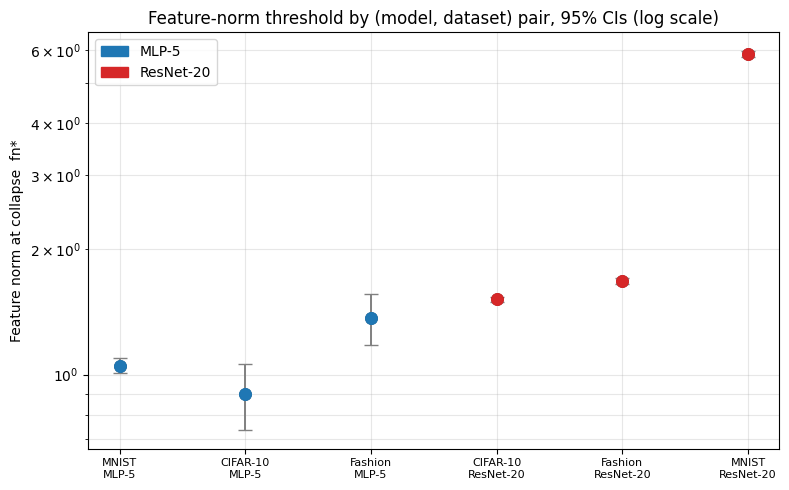

In [19]:
import matplotlib.pyplot as plt
order6=["MNIST/MLP-5","CIFAR-10/MLP-5","Fashion/MLP-5","CIFAR-10/ResNet-20","Fashion/ResNet-20","MNIST/ResNet-20"]
col=["#1F77B4","#1F77B4","#1F77B4","#D62728","#D62728","#D62728"]
means=[PAIR_VALS[k].mean() for k in order6]; cis=[tci(PAIR_VALS[k]) for k in order6]
err=[[m-lo for m,(lo,hi) in zip(means,cis)],[hi-m for m,(lo,hi) in zip(means,cis)]]
fig,ax=plt.subplots(figsize=(8,5))
ax.errorbar(range(6),means,yerr=err,fmt="o",ms=8,capsize=5,lw=1.4,ecolor="gray",mfc="white",mec="k",zorder=3)
for i,(mv,c) in enumerate(zip(means,col)): ax.scatter([i],[mv],s=70,color=c,zorder=4)
import matplotlib.patches as mp
ax.legend(handles=[mp.Patch(color="#1F77B4",label="MLP-5"),mp.Patch(color="#D62728",label="ResNet-20")],loc="upper left")
ax.set(yscale="log",xticks=range(6),ylabel="Feature norm at collapse  fn*",
       title="Feature-norm threshold by (model, dataset) pair, 95% CIs (log scale)")
ax.set_xticklabels([k.replace("/","\n") for k in order6],fontsize=8); ax.grid(alpha=.3,which="both")
plt.tight_layout(); plt.show()

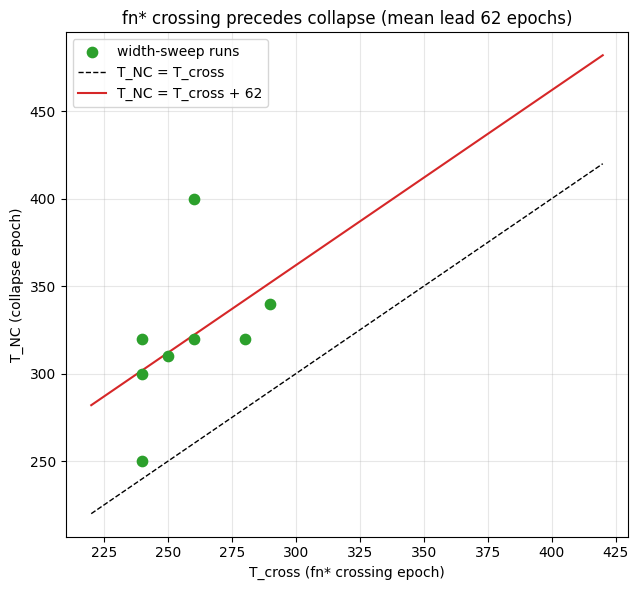

In [20]:
import matplotlib.pyplot as plt
pa=pd.read_csv(find("prediction_analysis.csv"))
fig,ax=plt.subplots(figsize=(6.5,6))
ax.scatter(pa.ep_cross,pa.T_NC,s=55,color="#2CA02C",zorder=3,label="width-sweep runs")
lim=[pa[["ep_cross","T_NC"]].min().min()-20, pa[["ep_cross","T_NC"]].max().max()+20]
ax.plot(lim,lim,"k--",lw=1,label="T_NC = T_cross"); xs=np.array(lim)
ax.plot(xs,xs+62,color="#D62728",lw=1.5,label="T_NC = T_cross + 62")
ax.set(xlabel="T_cross (fn* crossing epoch)",ylabel="T_NC (collapse epoch)",
       title="fn* crossing precedes collapse (mean lead %d epochs)"%pa.gap.mean())
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()